# Polynomial Regression — Interactive, Human-in-the-Loop Notebook

This notebook uses 5-fold cross-validation for model comparison, while still letting you inspect and override the final choices. It's built
so that after each numbered step you:

1. run the cell,
2. **look at the plot/output it produces**,
3. form your own judgement (and see what the code's own suggestion is),
4. write your decision into the small "Your decision" cell right after it,
5. move on.

Every later step only reads the small set of `CHOSEN_...` variables you set by hand — nothing is
silently auto-picked for you. If a later plot looks bad, scroll back up, change a `CHOSEN_...`
(or `FEATURES`, `DEGREE_RANGE_TO_TRY`, `LAMBDA_RANGE`, etc.), and re-run **from that cell down**.
You never need to re-run the whole notebook from the top.


In [42]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

torch.manual_seed(0)
np.random.seed(0)
plt.rcParams['figure.figsize'] = (7, 4.5)


## Step 0 — point this at your CSV, and choose where plots get saved

Edit the four variables below: which CSV, which column is the target, which feature columns to
use (`None` = use all of them), and where to save plots/config as you go.


In [43]:
TRAIN_CSV = "IMT2024076_train_var2.csv"     # <-- your personalised training file
TARGET = "y"
FEATURES = None                             # <-- e.g. ["x1", "x2", "x3"], or None for all except TARGET
OUT_DIR = "poly_reg_results_cv_2"             # <-- plots + model_config.json land here
N_FOLDS = 5                                 # <-- improved model-selection method

os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(TRAIN_CSV)
features = FEATURES or [c for c in df.columns if c != TARGET]
X_all = df[features].values.astype(np.float64)
y_all = df[TARGET].values.astype(np.float64)

if N_FOLDS < 2 or N_FOLDS > len(X_all):
    raise ValueError("N_FOLDS must be between 2 and the number of training rows")

kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"Loaded {len(df)} rows | features: {features}")
print(f"Model selection -> {N_FOLDS}-fold cross-validation (shuffle=True, random_state=42)")
df.head()


Loaded 1000 rows | features: ['x1', 'x2', 'x3']
Model selection -> 5-fold cross-validation (shuffle=True, random_state=42)


,x1,x2,x3,y
0,0.408146,0.496360,-0.209059,1.770657
1,-0.076855,1.000000,-0.708353,9.402635
2,0.059542,-1.000000,0.731662,-1.195911
3,-0.244547,0.825369,0.949649,7.058916
4,1.000000,0.083427,-0.202501,4.949059


## Step 1 — raw feature dependency

Run the cell below and just **look**: which features look flat/irrelevant against `y`? Which
look clearly curved (hinting you'll need degree > 1 on that feature)? No decision to record yet
— this is groundwork for the degree and regularisation choices later.


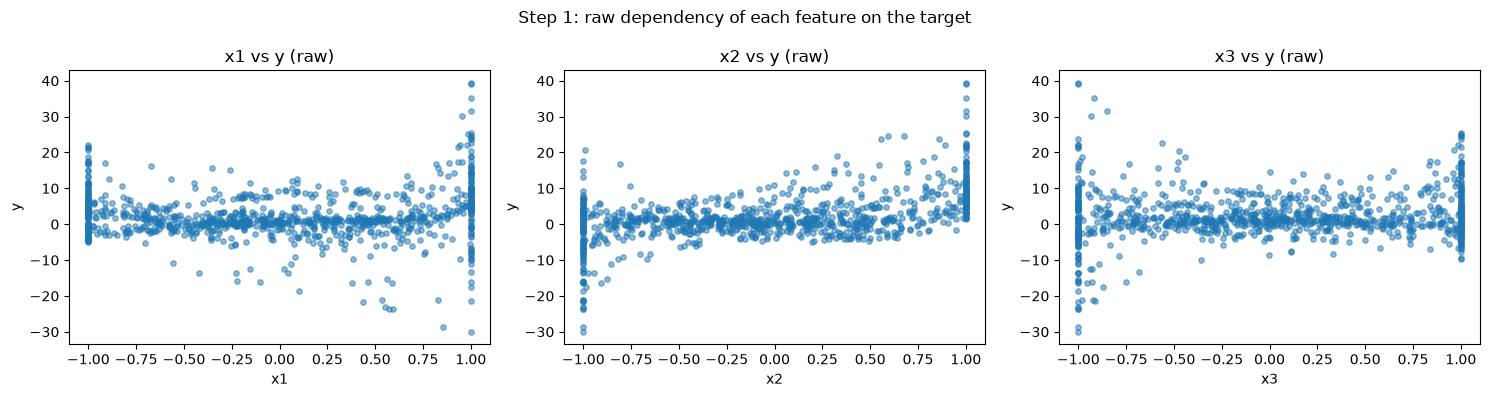

In [44]:
n_feat = len(features)
ncols = min(3, n_feat)
nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
for i, feat in enumerate(features):
    ax = axes[i // ncols][i % ncols]
    ax.scatter(X_all[:, i], y_all, alpha=0.5, s=15)
    ax.set_xlabel(feat); ax.set_ylabel(TARGET)
    ax.set_title(f"{feat} vs {TARGET} (raw)")
for j in range(n_feat, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.suptitle("Step 1: raw dependency of each feature on the target")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "01_feature_dependency_raw.png"), dpi=140)
plt.show()


## Step 2 — model + training helpers (run once)

Just the plumbing: a one-layer linear model (`y_hat = X @ w + b`), a PyTorch training loop that
can optionally add an L1 or L2 penalty on the weights, and small helpers for building polynomial
features and reading off term names. Nothing here makes a decision for you.


In [48]:
class LinearModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)
    def forward(self, x):
        return self.linear(x)


def train_linear_pytorch(X_train, y_train, X_val, y_val,
                          reg_type="none", lam=0.0,
                          epochs=3000, lr=0.02, patience=300):
    """reg_type: 'none' | 'l1' | 'l2'. Penalty applies to the weights only, never the bias."""
    Xtr_t = torch.tensor(X_train, dtype=torch.float32)
    ytr_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    has_val = X_val is not None and len(X_val) > 0
    if has_val:
        Xval_t = torch.tensor(X_val, dtype=torch.float32)
        yval_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    model = LinearModel(X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    train_hist, val_hist = [], []
    best_val, best_state, bad_epochs = np.inf, None, 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        pred = model(Xtr_t)
        data_loss = mse(pred, ytr_t)

        weight = model.linear.weight
        if reg_type == "l1":
            penalty = lam * weight.abs().sum()
        elif reg_type == "l2":
            penalty = lam * (weight ** 2).sum()
        else:
            penalty = torch.tensor(0.0)

        loss = data_loss + penalty
        loss.backward()
        optimizer.step()
        train_hist.append(data_loss.item())

        if has_val:
            model.eval()
            with torch.no_grad():
                val_loss = mse(model(Xval_t), yval_t).item()
            val_hist.append(val_loss)
            if val_loss < best_val - 1e-9:
                best_val, best_state, bad_epochs = val_loss, \
                    {k: v.clone() for k, v in model.state_dict().items()}, 0
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    break

    if has_val and best_state is not None:
        model.load_state_dict(best_state)
    return model, train_hist, val_hist


def build_poly(X_raw, degree, scaler=None, fit_scaler=False):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_raw)
    if fit_scaler:
        scaler = StandardScaler().fit(X_poly)
    return scaler.transform(X_poly), poly, scaler


def evaluate(model, X, y):
    Xt = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        pred = model(Xt).numpy().ravel()
    return mean_squared_error(y, pred), r2_score(y, pred), pred


def term_names(feature_names, degree):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    poly.fit(np.zeros((1, len(feature_names))))
    return poly.get_feature_names_out(feature_names)


def cv_candidate(degree, reg_type="none", lam=0.0, epochs=3000, lr=0.02):
    """Mean K-fold train/validation MSE. Polynomial features and scaler are fit inside each fold."""
    fold_train_mse, fold_val_mse, first_fold_w = [], [], None

    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all), start=1):
        Xtr_raw, Xval_raw = X_all[train_idx], X_all[val_idx]
        ytr, yval = y_all[train_idx], y_all[val_idx]

        Xtr_p, poly_fold, scaler_fold = build_poly(Xtr_raw, degree, fit_scaler=True)
        Xval_p = scaler_fold.transform(poly_fold.transform(Xval_raw))

        # Do not pass the CV validation fold into the optimiser.
        # This keeps the validation fold independent of early stopping/model fitting.
        model, _, _ = train_linear_pytorch(
            Xtr_p, ytr, None, None,
            reg_type=reg_type, lam=lam,
            epochs=epochs, lr=lr, patience=epochs)

        tr_mse, _, _ = evaluate(model, Xtr_p, ytr)
        val_mse, _, _ = evaluate(model, Xval_p, yval)
        fold_train_mse.append(tr_mse)
        fold_val_mse.append(val_mse)

        if first_fold_w is None:
            first_fold_w = model.linear.weight.detach().numpy().ravel().copy()

    return float(np.mean(fold_train_mse)), float(np.mean(fold_val_mse)), first_fold_w

print("Helpers defined, including K-fold CV.")


Helpers defined, including K-fold CV.


## Step 3 — term-importance check, BEFORE picking L1 vs L2

Expands to a rich polynomial (degree set below) and plots each term's raw correlation with `y`.
Look at the bar chart: is the effect **concentrated** in a handful of tall bars (hints L1 will
help — it can zero out the rest), or **spread thinly** across most of them (hints L2 will help
more, since it shrinks everything together instead of eliminating terms)? This is only a hint —
Step 5 tests both for real using validation error.



Term-importance check at degree=20 (before any regularisation):
  26% of the 1770 polynomial terms have |corr with y| < 0.05
  -> effect looks SPREAD across many terms: expect L2 to help more than L1.
  (this is only a hint from raw correlation -- the search below decides for real using validation MSE)


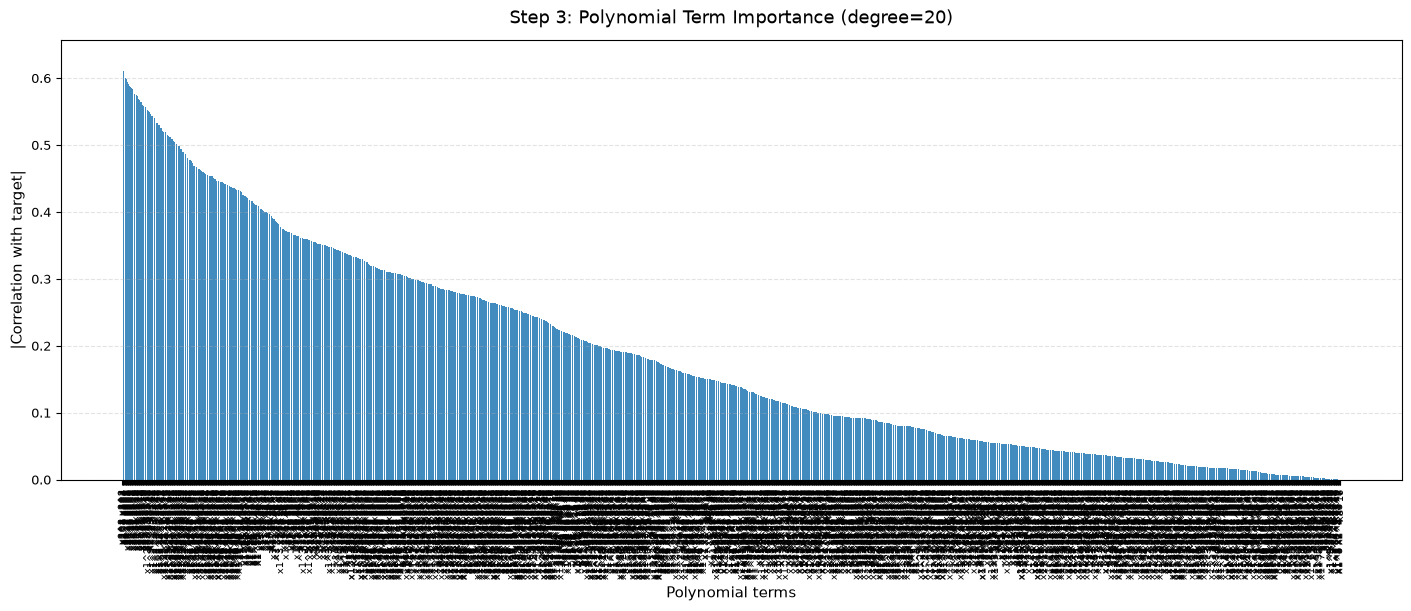

In [49]:
DEGREE_FOR_IMPORTANCE_CHECK = 20  # <-- change this if you want

# ---------------- 3. term-importance / dependency check, BEFORE picking L1 vs L2 ----------------
# Expand to the richest polynomial and inspect each polynomial term's raw
# correlation with the target. This is purely descriptive -- no model is fitted here.

Xrich, poly_rich, scaler_rich = build_poly(
    X_all,
    DEGREE_FOR_IMPORTANCE_CHECK,
    fit_scaler=True
)

rich_names = term_names(
    features,
    DEGREE_FOR_IMPORTANCE_CHECK
)

corr = np.array([
    np.corrcoef(Xrich[:, j], y_all)[0, 1]
    for j in range(Xrich.shape[1])
])

corr = np.nan_to_num(corr)

# Sort terms by absolute correlation, strongest first
order = np.argsort(-np.abs(corr))

frac_weak = float(np.mean(np.abs(corr) < 0.05))

print(
    f"\nTerm-importance check at degree={DEGREE_FOR_IMPORTANCE_CHECK} "
    f"(before any regularisation):"
)

print(
    f"  {frac_weak * 100:.0f}% of the {len(corr)} polynomial terms "
    f"have |corr with y| < 0.05"
)

if frac_weak > 0.5:
    print(
        "  -> effect looks CONCENTRATED in a few terms: "
        "expect L1 to help (it can zero out the rest)."
    )
else:
    print(
        "  -> effect looks SPREAD across many terms: "
        "expect L2 to help more than L1."
    )

print(
    "  (this is only a hint from raw correlation -- "
    "the search below decides for real using validation MSE)"
)


# ---------------- Step 3 plot ----------------
# Same data and same ordering as the original plot.
# Only the visual presentation is changed.

fig, ax = plt.subplots(
    figsize=(14, 6),
    constrained_layout=True
)

x_pos = np.arange(len(corr))

ax.bar(
    x_pos,
    np.abs(corr[order]),
    width=0.8,
    alpha=0.85
)

ax.set_xlabel(
    "Polynomial terms",
    fontsize=11
)

ax.set_ylabel(
    "|Correlation with target|",
    fontsize=11
)

ax.set_title(
    f"Step 3: Polynomial Term Importance "
    f"(degree={DEGREE_FOR_IMPORTANCE_CHECK})",
    fontsize=13,
    pad=12
)

# Terms are displayed in decreasing order of absolute correlation
ax.set_xticks(x_pos)

ax.set_xticklabels(
    [str(rich_names[i]) for i in order],
    rotation=90,
    fontsize=7
)

# Start y-axis at zero
ax.set_ylim(bottom=0)

# Horizontal grid for easier comparison
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.tick_params(
    axis="x",
    pad=4
)

ax.tick_params(
    axis="y",
    labelsize=9
)

# Save the plot
fig.savefig(
    os.path.join(
        OUT_DIR,
        "02_term_importance_dependency.png"
    ),
    dpi=180,
    bbox_inches="tight"
)

# Display inside Jupyter
plt.show()

# Close the figure after displaying/saving
plt.close(fig)

### Your judgement (just a note to yourself — nothing downstream reads this automatically)

In [50]:
MY_GUESS_REG_TYPE = "unsure"   # <-- edit: "l1" / "l2" / "unsure", based on the bar chart above
print(f"Your guess going into Step 5: {MY_GUESS_REG_TYPE}")


Your guess going into Step 5: unsure


## Step 4 — degree sweep (no regularisation yet)

Run it, look at the plot **and** the printed table, then make your own call on degree in the
"Your decision" cell right after — the code prints a suggested degree (lowest validation MSE)
but does not choose for you.


  degree  1 | mean CV train MSE=  32.8283 | mean CV MSE=  33.1370
  degree  2 | mean CV train MSE=  20.2596 | mean CV MSE=  20.7464
  degree  3 | mean CV train MSE=  10.2612 | mean CV MSE=  10.8934
  degree  4 | mean CV train MSE=   3.3431 | mean CV MSE=   3.7535
  degree  5 | mean CV train MSE=   1.2593 | mean CV MSE=   1.4633
  degree  6 | mean CV train MSE=   0.4924 | mean CV MSE=   0.6476
  degree  7 | mean CV train MSE=   0.2543 | mean CV MSE=   0.3418
  degree  8 | mean CV train MSE=   0.1880 | mean CV MSE=   0.2778
  degree  9 | mean CV train MSE=   0.1740 | mean CV MSE=   0.2653
  degree 10 | mean CV train MSE=   0.1585 | mean CV MSE=   0.2651
  degree 11 | mean CV train MSE=   0.1782 | mean CV MSE=   0.2793
  degree 12 | mean CV train MSE=   0.1531 | mean CV MSE=   0.2952
  degree 13 | mean CV train MSE=   0.1699 | mean CV MSE=   0.3083
  degree 14 | mean CV train MSE=   0.1442 | mean CV MSE=   0.3199
  degree 15 | mean CV train MSE=   0.1405 | mean CV MSE=   0.3287
  degree 1

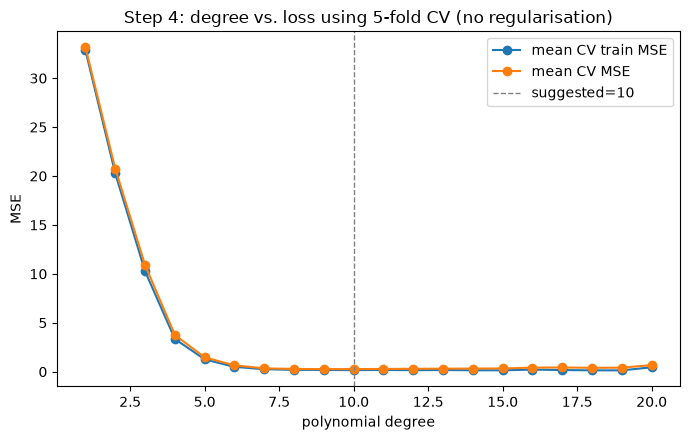

In [51]:
DEGREE_RANGE_TO_TRY = range(1, 21)   # assignment limit: degree 1 through 10

train_mse_by_deg, val_mse_by_deg = [], []
for d in DEGREE_RANGE_TO_TRY:
    tr_mse, val_mse, _ = cv_candidate(d, reg_type="none", lam=0.0)
    train_mse_by_deg.append(tr_mse)
    val_mse_by_deg.append(val_mse)
    print(f"  degree {d:2d} | mean CV train MSE={tr_mse:9.4f} | "
          f"mean CV MSE={val_mse:9.4f}")

degree_grid = list(DEGREE_RANGE_TO_TRY)
suggested_degree = degree_grid[int(np.argmin(val_mse_by_deg))]
print(f"\nCode's suggestion (lowest mean CV MSE, no regularisation): degree = {suggested_degree}")

fig, ax = plt.subplots()
ax.plot(degree_grid, train_mse_by_deg, "o-", label="mean CV train MSE")
ax.plot(degree_grid, val_mse_by_deg, "o-", label="mean CV MSE")
ax.axvline(suggested_degree, color="grey", ls="--", lw=1, label=f"suggested={suggested_degree}")
ax.set_xlabel("polynomial degree"); ax.set_ylabel("MSE")
ax.set_title("Step 4: degree vs. loss using 5-fold CV (no regularisation)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "03_degree_vs_loss_cv.png"), dpi=140)
plt.show()


### Your decision — set the degree you want to move forward with

Remember: this unregularised view can be misleading — a higher degree that looks like it's
overfitting here might still end up the better choice once Step 5 adds regularisation to it.
Feel free to pick something other than `suggested_degree` and see what Step 5 does with it.


In [52]:
CHOSEN_DEGREE = 9   # <-- EDIT to override; CV's suggestion is used by default
print(f"Moving forward with degree = {CHOSEN_DEGREE}")


Moving forward with degree = 9


## Step 5 — L1 vs L2 regularisation sweep, at `CHOSEN_DEGREE`

Builds polynomial features at your chosen degree, then sweeps a range of lambda values for L1
and for L2. Look at **both** plots: validation loss vs. lambda (which family gets lower, and at
what lambda), and the coefficient paths (does L1 actually zero out the terms Step 3 flagged as
weak? does L2 shrink more uniformly?). Then record your own choice below.


In [53]:
LAMBDA_RANGE = np.logspace(-4, 1.5, 14)   # <-- edit if you want a wider/narrower/denser sweep

names = term_names(features, CHOSEN_DEGREE)

# Evaluate every lambda using the SAME 5 CV folds.
_, no_reg_val_mse, _ = cv_candidate(CHOSEN_DEGREE, reg_type="none", lam=0.0)

curves = {"l1": [], "l2": []}
for reg_type in ["l1", "l2"]:
    for lam in LAMBDA_RANGE:
        _, val_mse, w = cv_candidate(CHOSEN_DEGREE, reg_type=reg_type, lam=float(lam))
        curves[reg_type].append((float(lam), val_mse, w))

best_l1 = min(curves["l1"], key=lambda t: t[1])
best_l2 = min(curves["l2"], key=lambda t: t[1])
print(f"no regularisation      | mean CV MSE={no_reg_val_mse:.4f}")
print(f"best L1 (lambda={best_l1[0]:.4g})  | mean CV MSE={best_l1[1]:.4f}")
print(f"best L2 (lambda={best_l2[0]:.4g})  | mean CV MSE={best_l2[1]:.4f}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(LAMBDA_RANGE, [t[1] for t in curves["l1"]], "o-", label="L1")
ax.plot(LAMBDA_RANGE, [t[1] for t in curves["l2"]], "o-", label="L2")
ax.axhline(no_reg_val_mse, color="grey", ls="--", lw=1, label="no regularisation")
ax.set_xscale("log"); ax.set_xlabel("lambda"); ax.set_ylabel("mean CV MSE")
ax.set_title(f"Step 5a: L1 vs L2 mean CV loss (degree={CHOSEN_DEGREE})")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "04_l1_vs_l2_loss_cv.png"), dpi=140)
plt.show()

for reg_type, fname, label in [("l1", "05_coef_path_l1.png", "L1"), ("l2", "06_coef_path_l2.png", "L2")]:
    coefs = np.array([t[2] for t in curves[reg_type]])
    fig, ax = plt.subplots(figsize=(8, 5))
    for j, name in enumerate(names):
        ax.plot(LAMBDA_RANGE, coefs[:, j], label=str(name))
    ax.set_xscale("log"); ax.set_xlabel("lambda"); ax.set_ylabel("coefficient value")
    ax.set_title(f"Step 5b: {label} coefficient path (degree={CHOSEN_DEGREE})")
    if len(names) <= 20:
        ax.legend(fontsize=7, ncol=2)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, fname), dpi=140)
    plt.show()


KeyboardInterrupt: 

### Your decision — set the regularisation you want to move forward with

In [36]:
CHOSEN_REG_TYPE = "l1" if best_l1[1] <= best_l2[1] and best_l1[1] <= no_reg_val_mse else "l2" if best_l2[1] <= no_reg_val_mse else "none"
CHOSEN_LAMBDA = float(best_l1[0] if CHOSEN_REG_TYPE == "l1" else best_l2[0] if CHOSEN_REG_TYPE == "l2" else 0.0)
# <-- EDIT either value manually if you want to inspect another choice.
print(f"Moving forward with reg_type={CHOSEN_REG_TYPE}, lambda={CHOSEN_LAMBDA:.5g}")


Moving forward with reg_type=l2, lambda=0.0007017


## Step 6 — final refit on ALL training rows, with your committed choices

Uses `CHOSEN_DEGREE`, `CHOSEN_REG_TYPE`, `CHOSEN_LAMBDA` exactly as you set them above. Look at
the diagnostics: does predicted-vs-actual hug the diagonal? Do residuals look patternless?


Final model on ALL training rows -> train MSE=0.1893, train R2=0.9959


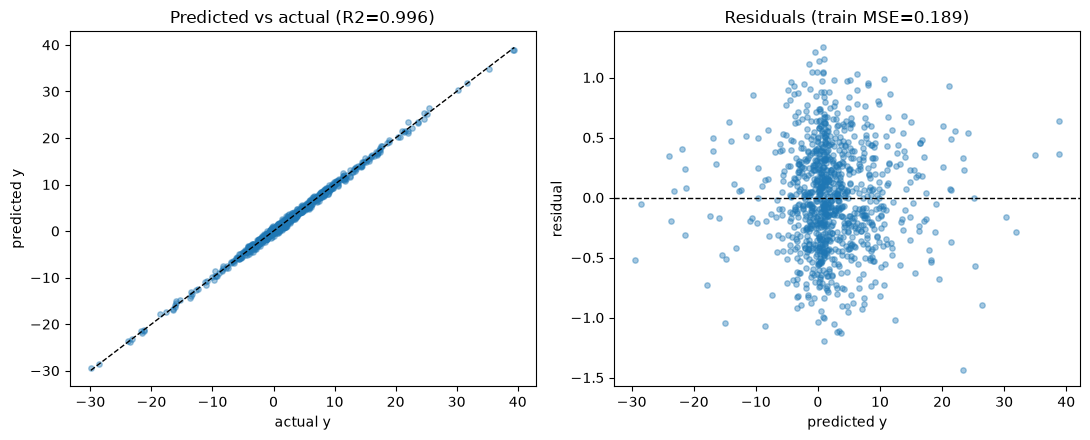

In [37]:
Xfull_p, poly_final, scaler_final = build_poly(X_all, CHOSEN_DEGREE, fit_scaler=True)
final_model, _, _ = train_linear_pytorch(Xfull_p, y_all, None, None,
                                          reg_type=CHOSEN_REG_TYPE, lam=CHOSEN_LAMBDA,
                                          epochs=3000, patience=3000)
final_mse, final_r2, final_pred = evaluate(final_model, Xfull_p, y_all)
print(f"Final model on ALL training rows -> train MSE={final_mse:.4f}, train R2={final_r2:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.scatter(y_all, final_pred, alpha=0.4, s=15)
lims = [min(y_all.min(), final_pred.min()), max(y_all.max(), final_pred.max())]
ax1.plot(lims, lims, "k--", lw=1)
ax1.set_xlabel("actual y"); ax1.set_ylabel("predicted y")
ax1.set_title(f"Predicted vs actual (R2={final_r2:.3f})")

residuals = y_all - final_pred
ax2.scatter(final_pred, residuals, alpha=0.4, s=15)
ax2.axhline(0, color="k", ls="--", lw=1)
ax2.set_xlabel("predicted y"); ax2.set_ylabel("residual")
ax2.set_title(f"Residuals (train MSE={final_mse:.3f})")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "07_final_diagnostics.png"), dpi=140)
plt.show()


## Step 7 — model-effect plots (partial dependence)

Vary one feature at a time, holding the others at their mean, and plot what the *final* model
predicts. Compare this against Step 1's raw plots — does the model's learned effect for each
feature make sense given the raw relationship you saw at the start?


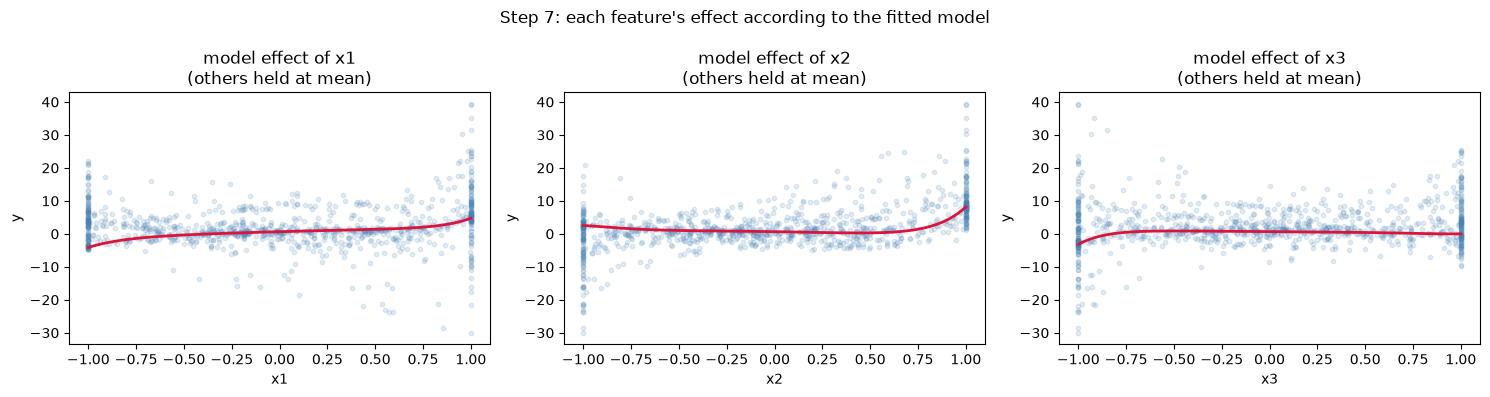

In [38]:
means = X_all.mean(axis=0)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
for i, feat in enumerate(features):
    ax = axes[i // ncols][i % ncols]
    grid = np.linspace(X_all[:, i].min(), X_all[:, i].max(), 100)
    X_vary = np.tile(means, (100, 1))
    X_vary[:, i] = grid
    X_vary_p = scaler_final.transform(poly_final.transform(X_vary))
    with torch.no_grad():
        y_vary = final_model(torch.tensor(X_vary_p, dtype=torch.float32)).numpy().ravel()
    ax.plot(grid, y_vary, color="crimson", lw=2)
    ax.scatter(X_all[:, i], y_all, alpha=0.15, s=10, color="steelblue")
    ax.set_xlabel(feat); ax.set_ylabel(TARGET)
    ax.set_title(f"model effect of {feat}\n(others held at mean)")
for j in range(n_feat, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")
fig.suptitle("Step 7: each feature's effect according to the fitted model")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "08_model_effect_per_feature.png"), dpi=140)
plt.show()


## Not happy with the fit? Loop back — you don't have to start over

Every step from Step 3 onward only reads variables you set by hand: `FEATURES`,
`DEGREE_FOR_IMPORTANCE_CHECK`, `DEGREE_RANGE_TO_TRY`, `CHOSEN_DEGREE`, `LAMBDA_RANGE`,
`CHOSEN_REG_TYPE`, `CHOSEN_LAMBDA`. Scroll back up, change whichever one you want to revisit,
and re-run **from that cell down** — the earlier cells' outputs (plots, printed tables) stay
right there for you to compare against your new run.

## Step 8 — save everything `predict_poly_regression.py` needs


In [41]:
config = {
    "features": features,
    "target": TARGET,
    "degree": CHOSEN_DEGREE,
    "reg_type": CHOSEN_REG_TYPE,
    "lambda": CHOSEN_LAMBDA,
    "scaler_mean": scaler_final.mean_.tolist(),
    "scaler_scale": scaler_final.scale_.tolist(),
    "weight": final_model.linear.weight.detach().numpy().ravel().tolist(),
    "bias": float(final_model.linear.bias.detach().numpy().ravel()[0]),
    "train_mse": final_mse,
    "train_r2": final_r2,
    "term_names": [str(n) for n in term_names(features, CHOSEN_DEGREE)],
}
config_path = os.path.join(OUT_DIR, "model_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved {config_path}")
print("Hand this file to predict_poly_regression.py --config to generate test predictions.")


Saved poly_reg_results_cv_2/model_config.json
Hand this file to predict_poly_regression.py --config to generate test predictions.
